# K-Means Clustering — Multiclass Credit Risk Grades (LendingClub)

## What algorithm are we using?
In this part of the assignment, we implement **K-Means**, an **unsupervised clustering** algorithm.  
Unlike classification models, K-Means does **not** use class labels during training.

K-Means attempts to partition the data into **$K$ clusters** by minimizing the within-cluster sum of squared distances:

$$
J = \sum_{n=1}^{N} \|x_n - \mu_{z_n}\|^2
$$

where:
- $x_n$ is a data point  
- $z_n$ is the cluster assignment for point $n$  
- $\mu_k$ is the centroid of cluster $k$  

---

## What problem are we solving here?

The dataset contains loan applicants with credit risk grades:

**grade ∈ {A, B, C, D, E, F, G}** (7 classes)

For this part of the assignment:
- credit grades are treated as **unknown during clustering**
- K-Means is run with **$K = 7$**, matching the number of possible grades  

After clustering, we **evaluate** how well the resulting clusters align with the true grades by assigning each cluster the most frequent grade within it.  
This evaluation is only used for reporting purposes; the grade labels are **not** used during clustering.


In [ ]:
from google.colab import drive
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# Paths
DATA_ROOT = Path("/content/drive/MyDrive/ML Project/Data")
TRAIN_DIR = DATA_ROOT / "Train"
TEST_DIR  = DATA_ROOT / "Test"

train_csv = TRAIN_DIR / "train.csv"
dev_csv   = TRAIN_DIR / "dev.csv"
test_csv  = TEST_DIR  / "test.csv"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())


print("Train CSV exists:", train_csv.exists(), train_csv)
print("Dev CSV exists:", dev_csv.exists(), dev_csv)
print("Test CSV exists:", test_csv.exists(), test_csv)


DATA_ROOT exists: True
TRAIN_DIR exists: True
TEST_DIR exists: True
Train CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/train.csv
Dev CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/dev.csv
Test CSV exists: True /content/drive/MyDrive/ML Project/Data/Test/test.csv


## Load train/dev/test CSV files

We load the preprocessed dataset splits from Google Drive.
We will keep the labels (`grade`, `grade_idx`) for evaluation only.
During K-Means training, we will **ignore** these labels.


In [ ]:
train_df = pd.read_csv(train_csv)
dev_df   = pd.read_csv(dev_csv)
test_df  = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:", list(train_df.columns))

# Basic check: target column exists
assert "grade_idx" in train_df.columns, "Expected 'grade_idx' in train.csv"
assert "grade_idx" in dev_df.columns, "Expected 'grade_idx' in dev.csv"
assert "grade_idx" in test_df.columns, "Expected 'grade_idx' in test.csv"

# Class distribution
print("\nTrain grade_idx counts:\n", train_df["grade_idx"].value_counts().sort_index())
print("\nDev grade_idx counts:\n", dev_df["grade_idx"].value_counts().sort_index())
print("\nTest grade_idx counts:\n", test_df["grade_idx"].value_counts().sort_index())

train_df.head()


Train shape: (59619, 24)
Dev shape: (12775, 24)
Test shape: (12782, 24)

Columns: ['grade', 'grade_idx', 'purpose', 'home_ownership', 'verification_status', 'addr_state', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']

Train grade_idx counts:
 grade_idx
0    8517
1    8517
2    8517
3    8517
4    8517
5    8517
6    8517
Name: count, dtype: int64

Dev grade_idx counts:
 grade_idx
0    1825
1    1825
2    1825
3    1825
4    1825
5    1825
6    1825
Name: count, dtype: int64

Test grade_idx counts:
 grade_idx
0    1826
1    1826
2    1826
3    1826
4    1826
5    1826
6    1826
Name: count, dtype: int64


,grade,grade_idx,purpose,home_ownership,verification_status,addr_state,loan_amnt,term,emp_length,annual_inc,...,total_acc,pub_rec,revol_bal,revol_util,collections_12_mths_ex_med,acc_now_delinq,pub_rec_bankruptcies,tax_liens,credit_history_months,fico_avg
0,D,3,credit_card,RENT,Verified,CA,6000.0,36.0,10.0,65000.0,...,55.0,1.0,1363.0,3.6,0.0,0.0,1.0,0.0,218.020534,677.0
1,G,6,small_business,MORTGAGE,Source Verified,OH,14600.0,36.0,3.0,60000.0,...,11.0,0.0,6995.0,88.5,0.0,0.0,0.0,0.0,259.055441,667.0
2,G,6,debt_consolidation,MORTGAGE,Source Verified,CA,35000.0,36.0,10.0,184000.0,...,22.0,1.0,37361.0,62.7,0.0,0.0,0.0,1.0,128.985626,682.0
3,E,4,debt_consolidation,RENT,Source Verified,IL,15000.0,60.0,2.0,30000.0,...,38.0,0.0,13211.0,63.5,0.0,0.0,0.0,0.0,132.008214,672.0
4,E,4,debt_consolidation,RENT,Verified,MD,15200.0,60.0,4.0,38000.0,...,10.0,0.0,5600.0,70.0,0.0,0.0,0.0,0.0,223.934292,697.0


## Quick sanity checks

We verify:
- required label columns exist
- class distribution per split
- feature columns look correct


In [ ]:
required_cols = {"grade", "grade_idx"}
print("Missing label cols in train:", required_cols - set(train_df.columns))
print("Missing label cols in dev:  ", required_cols - set(dev_df.columns))
print("Missing label cols in test: ", required_cols - set(test_df.columns))

print("\nTrain grade distribution:")
print(train_df["grade"].value_counts().sort_index())

print("\nDev grade distribution:")
print(dev_df["grade"].value_counts().sort_index())

print("\nTest grade distribution:")
print(test_df["grade"].value_counts().sort_index())

print("\nNumber of columns:", len(train_df.columns))
print("Columns:", list(train_df.columns))


Missing label cols in train: set()
Missing label cols in dev:   set()
Missing label cols in test:  set()

Train grade distribution:
grade
A    8517
B    8517
C    8517
D    8517
E    8517
F    8517
G    8517
Name: count, dtype: int64

Dev grade distribution:
grade
A    1825
B    1825
C    1825
D    1825
E    1825
F    1825
G    1825
Name: count, dtype: int64

Test grade distribution:
grade
A    1826
B    1826
C    1826
D    1826
E    1826
F    1826
G    1826
Name: count, dtype: int64

Number of columns: 24
Columns: ['grade', 'grade_idx', 'purpose', 'home_ownership', 'verification_status', 'addr_state', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']


## Preprocessing for K-Means

K-Means needs numeric vectors in a common scale.

Steps:
1. Split labels from features.
2. One-hot encode categorical features:
   - purpose, home_ownership, verification_status, addr_state
3. Handle missing values:
   - numeric: fill with train median
   - categorical: fill with "Unknown"
4. Standardize features using train mean/std (important for K-Means distance calculations).
5. Align dev/test columns to match train after one-hot encoding.


In [ ]:
# define feature sets (based on your project description)
CAT_COLS = ["purpose", "home_ownership", "verification_status"]  # addr_state removed

NUM_COLS = [
    "loan_amnt", "term", "emp_length", "annual_inc", "dti", "delinq_2yrs",
    "inq_last_6mths", "open_acc", "total_acc", "pub_rec", "revol_bal",
    "revol_util", "collections_12_mths_ex_med", "acc_now_delinq",
    "pub_rec_bankruptcies", "tax_liens", "credit_history_months", "fico_avg"
]

LABEL_COLS = ["grade", "grade_idx"]

def preprocess_fit_transform(train_df, dev_df, test_df,
                             cat_cols=CAT_COLS, num_cols=NUM_COLS,
                             label_cols=LABEL_COLS):
    # Copy to avoid modifying originals
    train = train_df.copy()
    dev   = dev_df.copy()
    test  = test_df.copy()

    # Fill missing categorical
    for c in cat_cols:
        train[c] = train[c].astype("object").fillna("Unknown")
        dev[c]   = dev[c].astype("object").fillna("Unknown")
        test[c]  = test[c].astype("object").fillna("Unknown")

    # Fill missing numeric (use train medians)
    train_medians = train[num_cols].median(numeric_only=True)
    train[num_cols] = train[num_cols].fillna(train_medians)
    dev[num_cols]   = dev[num_cols].fillna(train_medians)
    test[num_cols]  = test[num_cols].fillna(train_medians)

    # One-hot encode categorical using pandas (preprocessing allowed)
    X_train = pd.get_dummies(train[cat_cols + num_cols], columns=cat_cols, drop_first=False)
    X_dev   = pd.get_dummies(dev[cat_cols + num_cols], columns=cat_cols, drop_first=False)
    X_test  = pd.get_dummies(test[cat_cols + num_cols], columns=cat_cols, drop_first=False)

    # Align columns (dev/test may miss categories)
    X_dev  = X_dev.reindex(columns=X_train.columns, fill_value=0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Standardize ONLY numeric columns (keep one-hot as 0/1)
    X_train_std = X_train.copy()
    X_dev_std   = X_dev.copy()
    X_test_std  = X_test.copy()

    mu = X_train_std[num_cols].mean(axis=0)
    sigma = X_train_std[num_cols].std(axis=0).replace(0, 1.0)

    X_train_std[num_cols] = (X_train_std[num_cols] - mu) / sigma
    X_dev_std[num_cols]   = (X_dev_std[num_cols]   - mu) / sigma
    X_test_std[num_cols]  = (X_test_std[num_cols]  - mu) / sigma


    # Labels (for evaluation only)
    y_train = train["grade_idx"].to_numpy()
    y_dev   = dev["grade_idx"].to_numpy()
    y_test  = test["grade_idx"].to_numpy()

    feature_names = list(X_train.columns)

    return (X_train_std.to_numpy(dtype=np.float64),
            X_dev_std.to_numpy(dtype=np.float64),
            X_test_std.to_numpy(dtype=np.float64),
            y_train, y_dev, y_test,
            feature_names)

X_train, X_dev, X_test, y_train, y_dev, y_test, feature_names = preprocess_fit_transform(
    train_df, dev_df, test_df
)

print("X_train:", X_train.shape)
print("X_dev:  ", X_dev.shape)
print("X_test: ", X_test.shape)
print("Number of features after one-hot:", len(feature_names))


X_train: (59619, 41)
X_dev:   (12775, 41)
X_test:  (12782, 41)
Number of features after one-hot: 41


## Visualizing high-dimensional data in 2D with PCA (for plots only)

Our feature vectors are high-dimensional after one-hot encoding.
To visualize clustering results, we reduce to 2D using a simple PCA implementation (SVD-based).

This PCA is only for visualization and does not affect K-Means training.


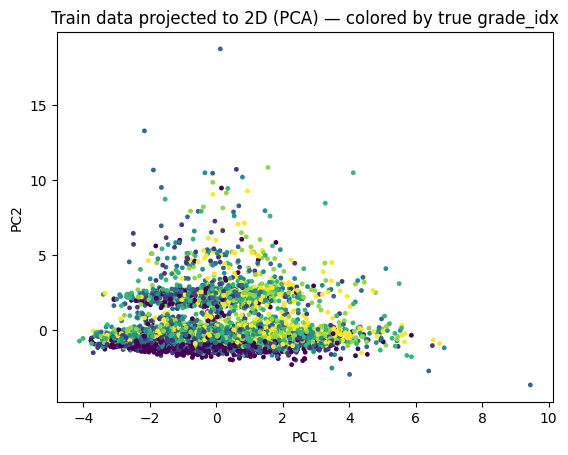

In [ ]:
def pca_reduce(X, n_components=2):
    # Center
    Xc = X - X.mean(axis=0, keepdims=True)
    # SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    # Project
    return Xc @ Vt[:n_components].T

# Use a subset for faster plotting
np.random.seed(0)
plot_n = min(8000, X_train.shape[0])
idx = np.random.choice(X_train.shape[0], size=plot_n, replace=False)

X2 = pca_reduce(X_train[idx], n_components=2)

plt.figure()
plt.scatter(X2[:,0], X2[:,1], s=6, c=y_train[idx])
plt.title("Train data projected to 2D (PCA) — colored by true grade_idx")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Implement K-Means

We implement K-Means similarly to the lab:
- initialize K centroids from random training points
- repeat:
  - assign points to nearest centroid
  - update centroids as mean of assigned points
- track objective (inertia): sum of squared distances to assigned centroids

We also support `n_init` (multiple random restarts) and keep the best solution.


In [ ]:
def kmeans_fit(X, K, max_iter=100, tol=1e-4, n_init=5, seed=0, verbose=True):

    #X: (N, D)
    #Returns best_centroids, best_assignments, best_inertia_history

    rng = np.random.default_rng(seed)
    N, D = X.shape

    def inertia(X, C, z):
        # sum ||x_n - C[z_n]||^2
        diff = X - C[z]
        return float(np.sum(diff * diff))

    best_C = None
    best_z = None
    best_hist = None
    best_J = np.inf

    # Precompute X squared norms for fast distance computation
    X_norm2 = np.sum(X * X, axis=1, keepdims=True)  # (N, 1)

    for init in range(n_init):
        # init centroids: choose K random distinct points
        init_idx = rng.choice(N, size=K, replace=False)
        C = X[init_idx].copy()  # (K, D)



        hist = []
        z_prev = None

        for it in range(max_iter):
            # compute squared distances efficiently
            # dist^2(x, c) = ||x||^2 + ||c||^2 - 2 x·c
            C_norm2 = np.sum(C * C, axis=1, keepdims=True).T  # (1, K)
            dist2 = X_norm2 + C_norm2 - 2.0 * (X @ C.T)       # (N, K)

            # Assignment
            z = np.argmin(dist2, axis=1)  # (N,)

            # Update centroids
            C_new = np.zeros_like(C)
            for k in range(K):
                members = X[z == k]
                if len(members) == 0:
                    # empty cluster -> reinitialize to a random point
                    C_new[k] = X[rng.integers(0, N)]
                else:
                    C_new[k] = members.mean(axis=0)

            # Track objective
            J = inertia(X, C_new, z)
            hist.append(J)

            # Convergence checks
            if z_prev is not None:
                frac_changed = np.mean(z != z_prev)
                if verbose and (it % 10 == 0 or it == max_iter - 1):
                    print(f"[init {init+1}/{n_init}] iter {it:03d}  inertia={J:.2f}  changed={frac_changed:.4f}")

                if frac_changed == 0:
                    C = C_new
                    break

            # centroid shift
            shift = np.linalg.norm(C_new - C) / (np.linalg.norm(C) + 1e-12)
            C = C_new
            z_prev = z

            if shift < tol:
                break

        # keep best init
        if hist[-1] < best_J:
            best_J = hist[-1]
            best_C = C
            best_z = z
            best_hist = hist

    return best_C, best_z, best_hist

def kmeans_predict(X, C):
    # Assign each x to nearest centroid in C
    X_norm2 = np.sum(X * X, axis=1, keepdims=True)          # (N, 1)
    C_norm2 = np.sum(C * C, axis=1, keepdims=True).T        # (1, K)
    dist2 = X_norm2 + C_norm2 - 2.0 * (X @ C.T)             # (N, K)
    return np.argmin(dist2, axis=1)


## Run K-Means (K = 7)

- We run K-Means with number of clusters equal to the number of dataset classes.
- Here, grades A–G → K = 7.

We fit using training features only and ignore labels during training.
We also plot the inertia across iterations.


### Why plot inertia vs. iteration for K-Means?

K-Means runs iteratively, alternating between assigning points to the nearest centroid and updating the centroids. During this process, the objective value should steadily improve. Plotting inertia across iterations lets us verify that the algorithm is actually converging and not stuck or oscillating.

### What is inertia in this context?

Inertia is the K-Means objective function. It measures how tightly the data points are grouped around their assigned cluster centroids. It is defined as the sum of squared distances from each sample to its cluster center:

$$
\text{Inertia} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

Lower inertia means tighter clusters and a better overall fit. As K-Means iterates, inertia should decrease and eventually flatten once the algorithm has converged.


[init 1/5] iter 010  inertia=874936.50  changed=0.0098
[init 1/5] iter 020  inertia=873257.27  changed=0.0157
[init 1/5] iter 030  inertia=865237.31  changed=0.0290
[init 1/5] iter 040  inertia=849799.81  changed=0.0262
[init 1/5] iter 050  inertia=836500.85  changed=0.0016
[init 1/5] iter 059  inertia=836494.43  changed=0.0001
[init 2/5] iter 010  inertia=899703.83  changed=0.0412
[init 2/5] iter 020  inertia=862554.47  changed=0.0024
[init 3/5] iter 010  inertia=872928.51  changed=0.0109
[init 3/5] iter 020  inertia=855737.34  changed=0.0030
[init 3/5] iter 030  inertia=855680.58  changed=0.0011
[init 3/5] iter 040  inertia=855674.66  changed=0.0002
[init 4/5] iter 010  inertia=899482.58  changed=0.0256
[init 4/5] iter 020  inertia=894624.08  changed=0.0114
[init 4/5] iter 030  inertia=893598.59  changed=0.0037
[init 4/5] iter 040  inertia=893553.28  changed=0.0008
[init 4/5] iter 050  inertia=893546.06  changed=0.0005
[init 4/5] iter 059  inertia=893517.14  changed=0.0012
[init 5/5]

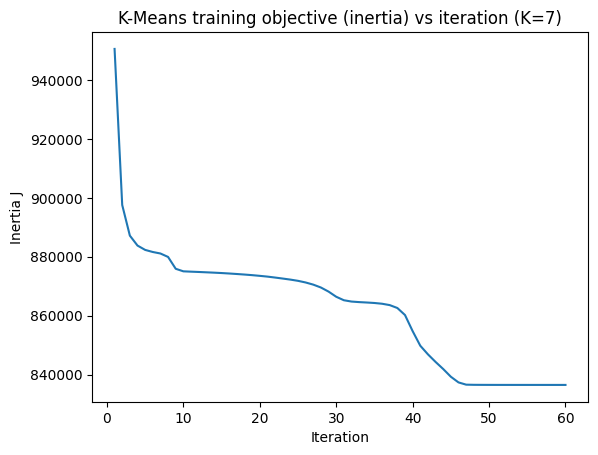

Final inertia: 836494.4338979349
Centroids shape: (7, 41)
Cluster counts: [ 8171 16713 15512  7207 10118  1286   612]


In [ ]:
K = 7
C, z_train, inertia_hist = kmeans_fit(
    X_train, K=K,
    max_iter=60,
    tol=1e-4,
    n_init=5,
    seed=42,
    verbose=True
)

plt.figure()
plt.plot(range(1, len(inertia_hist)+1), inertia_hist)
plt.title(f"K-Means training objective (inertia) vs iteration (K={K})")
plt.xlabel("Iteration")
plt.ylabel("Inertia J")
plt.show()


print("Final inertia:", inertia_hist[-1])
print("Centroids shape:", C.shape)
print("Cluster counts:", np.bincount(z_train, minlength=K))


## Evaluate clustering vs true grades (post-hoc, for reporting)

K-Means produces clusters 0..K-1 with no meaning.

To compare with the real grades A..G, we map each cluster to a grade label using:
- **majority vote**: the most common true grade in that cluster (computed on train)

Then we can compute:
- train accuracy (after mapping)
- dev/test accuracy (using same mapping learned on train)
- confusion matrix (grades vs predicted grades)

This does not affect clustering (labels are not used in fitting).


In [ ]:
GRADE_NAMES = np.array(["A","B","C","D","E","F","G"])

def cluster_to_label_mapping(z, y, K):
    """
    Build mapping cluster k -> label in {0..6} using majority vote on provided data.
    """
    mapping = np.zeros(K, dtype=int)
    for k in range(K):
        ys = y[z == k]
        if len(ys) == 0:
            mapping[k] = 0  # default if empty
        else:
            mapping[k] = np.bincount(ys, minlength=7).argmax()
    return mapping

def apply_mapping(z, mapping):
    return mapping[z]

def accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def confusion_matrix(y_true, y_pred, num_classes=7):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for a, b in zip(y_true, y_pred):
        cm[a, b] += 1
    return cm

# Learn mapping on TRAIN (post-hoc)
mapping = cluster_to_label_mapping(z_train, y_train, K=K)
print("Cluster -> grade_idx mapping:", mapping)
print("Cluster -> grade label mapping:", GRADE_NAMES[mapping])

# Predictions (train/dev/test)
yhat_train = apply_mapping(z_train, mapping)

z_dev  = kmeans_predict(X_dev,  C)
z_test = kmeans_predict(X_test, C)

yhat_dev  = apply_mapping(z_dev,  mapping)
yhat_test = apply_mapping(z_test, mapping)

print("\nAccuracies after majority-vote mapping:")
print("Train accuracy:", accuracy(y_train, yhat_train))
print("Dev accuracy:  ", accuracy(y_dev,   yhat_dev))
print("Test accuracy: ", accuracy(y_test,  yhat_test))

cm_test = confusion_matrix(y_test, yhat_test, num_classes=7)
print("\nConfusion Matrix (Test) rows=true, cols=pred (grade_idx 0..6):")
print(cm_test)


Cluster -> grade_idx mapping: [0 6 1 2 6 3 5]
Cluster -> grade label mapping: ['A' 'G' 'B' 'C' 'G' 'D' 'F']

Accuracies after majority-vote mapping:
Train accuracy: 0.2583572351096127
Dev accuracy:   0.2607436399217221
Test accuracy:  0.2576279142544203

Confusion Matrix (Test) rows=true, cols=pred (grade_idx 0..6):
[[ 977  426  111   16    0   12  284]
 [ 366  730  218   43    0   19  450]
 [ 148  685  259   36    0   20  678]
 [  82  643  252   32    0   17  800]
 [  76  433  242   35    0   13 1027]
 [  54  259  216   50    0   16 1231]
 [  44  187  242   48    0   26 1279]]


## Visualizing clusters (2D PCA)

We project train points to 2D using PCA (for visualization only) and color them by:
- K-Means cluster id
and optionally overlay approximate centroid locations in the same 2D projection.

To visualize how K-Means partitions the data, we projected the training points and the learned centroids into 2D using PCA. Points are colored by their assigned cluster, and centroids are shown as large "X" markers. The plot shows that while there is some overlap between clusters, the centroids capture different regions of the PCA space and reflect patterns in the data distribution.

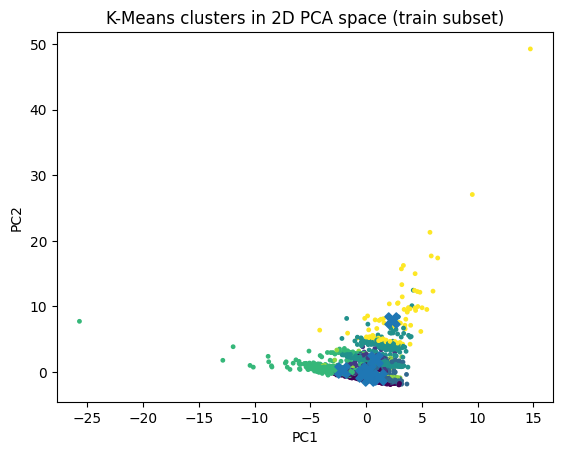

In [ ]:
# PCA projection for plotting (subset for speed)
np.random.seed(1)
plot_n = min(8000, X_train.shape[0])
idx = np.random.choice(X_train.shape[0], size=plot_n, replace=False)

X_train_sub = X_train[idx]
z_sub = z_train[idx]
X2_sub = pca_reduce(X_train_sub, n_components=2)

# Project centroids too (same PCA basis requires doing PCA on combined set or reusing basis)
# For simplicity: PCA on subset+centroids together to plot both consistently
X_combo = np.vstack([X_train_sub, C])
X2_combo = pca_reduce(X_combo, n_components=2)
X2_pts = X2_combo[:-K]
X2_cent = X2_combo[-K:]

plt.figure()
plt.scatter(X2_pts[:,0], X2_pts[:,1], s=6, c=z_sub)
plt.scatter(X2_cent[:,0], X2_cent[:,1], s=120, marker="X")
plt.title("K-Means clusters in 2D PCA space (train subset)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Notes / interpretation

- Because this is unsupervised, clusters may not align well with grades (that is OK).
- K-Means assumes roughly spherical clusters in Euclidean space and is sensitive to scaling.
- One-hot encoded categorical variables can dominate distances; standardization helps but the geometry can still be imperfect.
- The inertia curve should decrease and then stabilize as K-Means converges.




Conclusion

The K-Means algorithm was applied to the credit risk dataset using a number of clusters equal to the true number of classes (7). Since K-Means is an unsupervised method, it does not use label information during training, and the resulting clusters do not perfectly align with the true credit grades. Nevertheless, the algorithm was able to capture some underlying structure in the data, grouping together applicants with similar financial characteristics. The results highlight the limitations of K-Means for complex, high-dimensional financial data, but also demonstrate its usefulness as an exploratory clustering technique.